In [1]:
import cf_xarray # gives the ds.cf and da.cf objects
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
from cmocean.tools import crop_by_percent
import gsw
import xgcm

In [2]:
from dask.distributed import Client
client = Client(n_workers=4, threads_per_worker=1, memory_limit='auto')
client

/opt/tljh/user/lib/python3.7/site-packages/distributed/node.py:155: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44475 instead
  http_address["port"], self.http_server.port


Client Scheduler: tcp://127.0.0.1:44805 Dashboard: http://127.0.0.1:44475/status,Cluster Workers: 4 Cores: 4 Memory: 16.75 GB


# Open data and create grid

In [3]:
from pathlib import Path
datadir = Path('../data/processed/')
datadirraw = Path('../data/raw/interp_monthly/')

In [4]:
def preprocess(ds):
    if 'Z' in ds.variables:
        ds['Z'] = - ds.Z
        ds = ds.rename({'Z':'depth'})
    return ds

ds = xr.open_mfdataset([*datadirraw.glob('**/*.nc'), *datadir.glob('depth_metrics.nc')], preprocess=preprocess)
ds

<xarray.Dataset>
Dimensions:     (depth_left: 50, i: 720, j: 360, k: 50, nv: 2, time: 252)
Coordinates:
    dzc         (depth_left) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    dzt         (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
  * depth_left  (depth_left) float32 0.0 10.0 20.0 ... 4839.75 5250.25 5683.75
  * k           (k) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49
    depth       (k) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    longitude   (i) float64 dask.array<chunksize=(720,), meta=np.ndarray>
    latitude    (j) float64 dask.array<chunksize=(360,), meta=np.ndarray>
  * j           (j) int64 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
  * i           (i) int64 0 1 2 3 4 5 6 7 8 ... 712 713 714 715 716 717 718 719
  * time        (time) datetime64[ns] 1997-01-16T12:00:00 ... 2017-12-16
    timestep    (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
    time_bnds   (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    MXLDEPTH    (time, j, i) float64 dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SALT        (time, k, j, i) float64 dask.array<chunksize=(1, 50, 360, 720), meta=np.ndarray>
    THETA       (time, k, j, i) float64 dask.array<chunksize=(1, 50, 360, 720), meta=np.ndarray>
Attributes:
    product_time_coverage_start:  1992-01-01T12:00:00
    author:                       Ou Wang and Ian Fenty
    Insitution:                   JPL
    product_version:              ECCO Version 4 Release 4
    time_units:                   days since 1992-01-01 00:00:00
    Conventions:                  CF-1.6
    Project:                      Estimating the Circulation and Climate of t...
    cdm_data_type:                Grid
    geospatial_lon_units:         degrees_east
    Metadata_Conventions:         CF-1.6, Unidata Dataset Discovery v1.0, GDS...
    no_data:                      NaNf
    geospatial_lat_units:         degrees_north
    product_time_coverage_end:    2017-12-31T12:00:00
    geospatial_vertical_min:      -5906.25
    nz:                           50
    geospatial_vertical_units:    meter
    geospatial_vertical_max:      -5.0
    date_created:                 Thu Aug 22 18:56:33 2019
    time_coverage_start:          2013-12-01T00:00:00
    time_coverage_end:            2014-01-01T00:00:00

In [5]:
ds['dzt'] = ds.dzt.fillna(0)
ds['dzc'] = ds.dzc.fillna(0)

In [6]:
grid = xgcm.Grid(ds, periodic=False, metrics={('Z',):['dzc', 'dzt']})
grid

<xgcm.Grid>
Y Axis (not periodic, boundary=None):
  * center   j
T Axis (not periodic, boundary=None):
  * center   time
X Axis (not periodic, boundary=None):
  * center   i
Z Axis (not periodic, boundary=None):
  * center   k --> left
  * left     depth_left --> center

# Compute thermodynamic properties and the TEC

In [7]:
ds['SA'] = gsw.conversions.SA_from_SP(ds.SALT, ds.depth, ds.longitude, ds.latitude)
ds['CT'] = gsw.conversions.CT_from_pt(SA=ds.SA, pt=ds.THETA)
ds['alpha'] = gsw.density.alpha(SA=ds.SA, CT=ds.CT, p=ds.depth)
#ds['beta']= gsw.density.beta(SA=ds.SA, CT=ds.CT, p=ds.depth)
for i in ['SA', 'CT', 'alpha']:
    ds[i].attrs = []

In [8]:
ds['alpha_mixed_layer'] = grid.average(ds.alpha.where(ds.depth < ds.MXLDEPTH), 'Z').rename('alpha_mixed_layer')
ds.alpha_mixed_layer.attrs.update(
    {'long_name':'thermal expansion coefficient average of the mixed layer', 'unit':'degC-1'}
)

In [9]:
ds['alpha_surface'] = ds.alpha.isel(k=0).rename('alpha_surface')
ds.alpha_surface.attrs.update(
    {'long_name':'thermal expansion coefficient at the surface', 'unit':'degC-1'}
)

In [10]:
ds[['alpha_mixed_layer', 'alpha_surface']].mean('time').to_netcdf(datadir / 'surface_tec.nc')

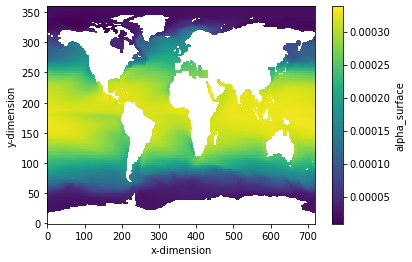

In [11]:
ds.alpha_surface.where(ds.MXLDEPTH>0).mean('time').plot(center=False)

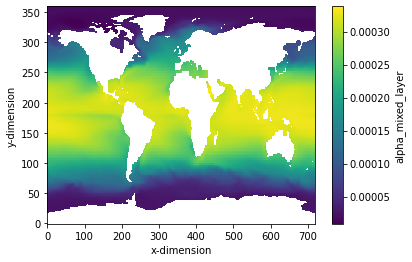

In [12]:
ds.alpha_mixed_layer.mean('time').plot(center=False)